In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load raw data

In [2]:
df = pd.read_csv('../../data/processed/processed_data.csv')

In [ ]:
# Time based columns as they are arbitrary as time grows and time_since_last_transactions captures better meaning
df.drop(columns=["customer_prev_step", "customer_prev_merchant_step", "merchant_prev_step"], inplace=True)

# Sums and averages are captured in the ratios and z-scores, so can drop them to reduce dimensionality
df.drop(columns=["customer_amount_sum", "customer_avg_amount", "merchant_past_amount_sum", "merchant_avg_amount", "global_amount_sum"], inplace=True)

# Was only used to dervive fraud rate, can drop it now
df.drop(columns=["merchant_fraud_count"], inplace=True)

# Dropping from data analyisis, median captures more of the more common transaction amounts, compared to the mean
df.drop(columns=["global_avg_amount", "global_amount_ratio", "global_log_amount_ratio", "global_median_amount"], inplace=True)

# From Permutation graphs log values tend to do better
df.drop(columns=["customer_avg_amount_ratio", "merchant_avg_amount_ratio", "global_median_amount_ratio"], inplace=True)

In [3]:
df[df.duplicated()]

,step,customer,merchant,customer_amount,fraud,customer_time_since_last_transaction,customer_transaction_count,customer_std_amount,customer_log_amount_ratio,customer_zscore,...,category_es_home,category_es_hotelservices,category_es_hyper,category_es_leisure,category_es_otherservices,category_es_sportsandtoys,category_es_tech,category_es_transportation,category_es_travel,category_es_wellnessandbeauty


### Check for outliers
Do not remove during data preparation. Outliers are crutial for detecting anomalies such as fraud transactions.

In [4]:
cat_cols, cont_cols, binary_cols = [], [], []

for col in df.columns:
    if df[col].dtype == "str":
        cat_cols.append(col)
    else:
        if df[col].nunique() > 2:
            cont_cols.append(col)
        else:
            binary_cols.append(col)


print("Categorical Columns:", cat_cols)
print("Continuous Columns:", cont_cols)
print("Binary Columns:", binary_cols)

Categorical Columns: ['customer', 'merchant']
Continuous Columns: ['step', 'customer_amount', 'customer_time_since_last_transaction', 'customer_transaction_count', 'customer_std_amount', 'customer_log_amount_ratio', 'customer_zscore', 'customer_merchant_count', 'customer_category_count', 'customer_time_since_last_merchant_transaction', 'merchant_transaction_count', 'merchant_std_amount', 'merchant_log_amount_ratio', 'merchant_amount_zscore', 'merchant_fraud_rate', 'merchant_time_since_last_transaction', 'global_std_amount', 'global_z_score', 'global_log_median_amount_ratio']
Binary Columns: ['fraud', "age_'0'", "age_'1'", "age_'2'", "age_'3'", "age_'4'", "age_'5'", "age_'6'", "age_'U'", "gender_'E'", "gender_'F'", "gender_'M'", "gender_'U'", 'category_es_barsandrestaurants', 'category_es_contents', 'category_es_fashion', 'category_es_food', 'category_es_health', 'category_es_home', 'category_es_hotelservices', 'category_es_hyper', 'category_es_leisure', 'category_es_otherservices', 'ca

In [5]:
feature_dict = {"global" : [], "customer": [], "merchant": [], "other": []}

for col in cont_cols:
    if col.startswith("global_"):
        feature_dict["global"].append(col)
    elif col.startswith("customer"):
        feature_dict["customer"].append(col)
    elif col.startswith("merchant"):
        feature_dict["merchant"].append(col)
    else:
        feature_dict["other"].append(col)

print("Global Features:", feature_dict["global"])
print("Customer Features:", feature_dict["customer"])
print("Merchant Features:", feature_dict["merchant"])
print("Other Features:", feature_dict["other"])

Global Features: ['global_std_amount', 'global_z_score', 'global_log_median_amount_ratio']
Customer Features: ['customer_amount', 'customer_time_since_last_transaction', 'customer_transaction_count', 'customer_std_amount', 'customer_log_amount_ratio', 'customer_zscore', 'customer_merchant_count', 'customer_category_count', 'customer_time_since_last_merchant_transaction']
Merchant Features: ['merchant_transaction_count', 'merchant_std_amount', 'merchant_log_amount_ratio', 'merchant_amount_zscore', 'merchant_fraud_rate', 'merchant_time_since_last_transaction']
Other Features: ['step']


### Check class distribution
If classes are imbalanced, avoid using Accuracy metric. Use F1 Score, Percision and Recall instead to measure model preformance.

In [6]:
# count values of classifier column
fraud_counts = df['fraud'].map({0: "No", 1: "Yes"}).value_counts()

bin_dict = {"age": [], "gender": []}
for col in binary_cols:
    if col.startswith("age"):
        bin_dict["age"].append(col)
    elif col.startswith("gender"):
        bin_dict["gender"].append(col)

age_counts = df[bin_dict["age"]].sum()
gender_counts = df[bin_dict["gender"]].sum()

print("Fraud Counts:", fraud_counts)
print("\nAge Counts:\n", age_counts)
print("\nGender Counts:\n", gender_counts)

Fraud Counts: fraud
No     587442
Yes      7200
Name: count, dtype: int64

Age Counts:
 age_'0'      2452
age_'1'     58131
age_'2'    187310
age_'3'    147131
age_'4'    109024
age_'5'     62642
age_'6'     26774
age_'U'      1178
dtype: int64

Gender Counts:
 gender_'E'      1178
gender_'F'    324565
gender_'M'    268384
gender_'U'       515
dtype: int64


In [7]:
def pie_with_arrows(ax, data, title):
    wedges, _ = ax.pie(data, startangle=90)
    ax.set_title(title)

    for i, wedge in enumerate(wedges):
        angle = (wedge.theta2 + wedge.theta1) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))

        label = f"{data.index[i]}: {data.iloc[i] / data.sum() * 100:.1f}%"

        ax.annotate(
            label,
            xy=(x, y),
            xytext=(1.2 * np.sign(x), 1.2 * y),
            arrowprops=dict(arrowstyle="-"),
            ha="left" if x > 0 else "right"
        )

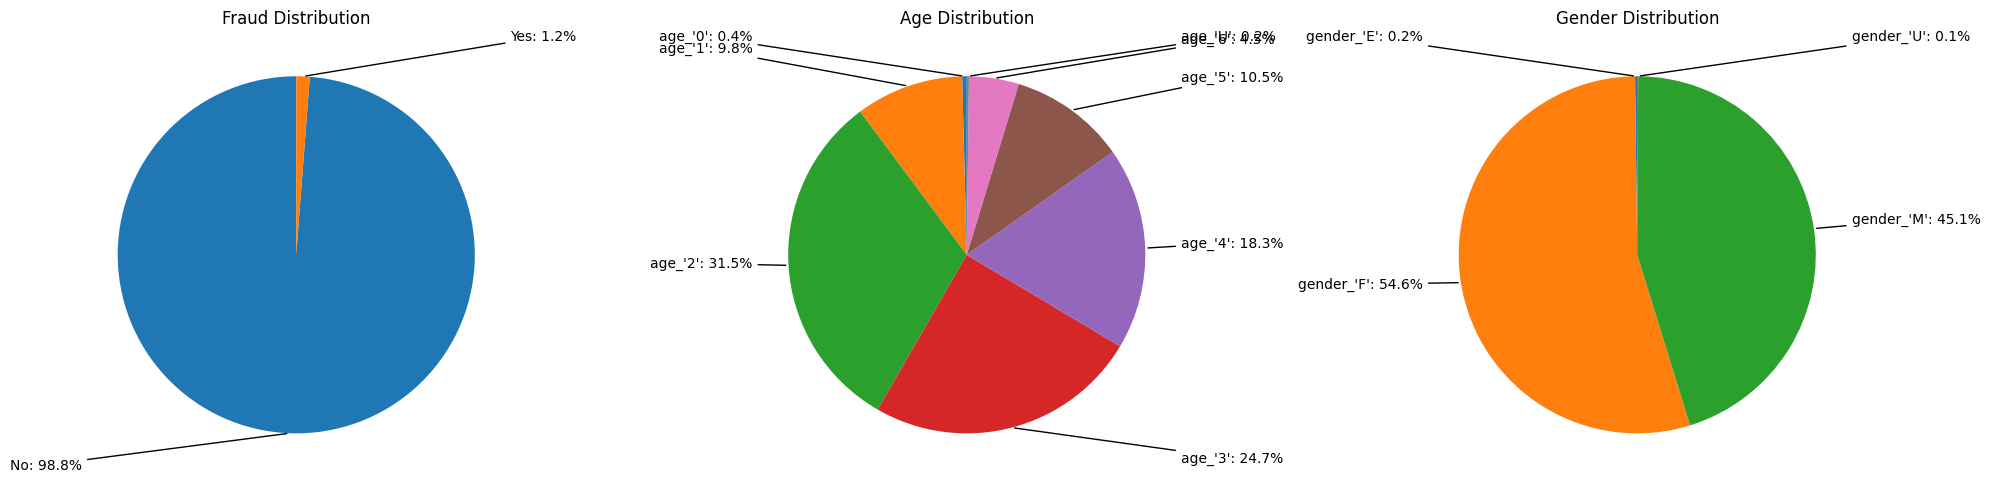

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

pie_with_arrows(axes[0], fraud_counts, "Fraud Distribution")
pie_with_arrows(axes[1], age_counts, "Age Distribution")
pie_with_arrows(axes[2], gender_counts, "Gender Distribution")

plt.tight_layout()
plt.show()

### Variance Calculation
Looks at the number of unique values in a column if its just 1 drop it


In [9]:
cols_to_drop = []
for col in df.columns:
   unum = df[col].nunique()

   print(f"Unique numbers of {col}s:", unum)

   if unum == 1:
      cols_to_drop.append(col)

print("\nDropping columns due to constant values:", cols_to_drop)

for col in cols_to_drop:
   cat_cols.remove(col)

df.drop(columns=cols_to_drop, inplace=True)

Unique numbers of steps: 180
Unique numbers of customers: 4112
Unique numbers of merchants: 50
Unique numbers of customer_amounts: 23767
Unique numbers of frauds: 2
Unique numbers of customer_time_since_last_transactions: 95
Unique numbers of customer_transaction_counts: 265
Unique numbers of customer_std_amounts: 590179
Unique numbers of customer_log_amount_ratios: 590324
Unique numbers of customer_zscores: 586416
Unique numbers of customer_merchant_counts: 163
Unique numbers of customer_category_counts: 169
Unique numbers of customer_time_since_last_merchant_transactions: 176
Unique numbers of merchant_transaction_counts: 299693
Unique numbers of merchant_std_amounts: 594592
Unique numbers of merchant_log_amount_ratios: 594542
Unique numbers of merchant_amount_zscores: 594543
Unique numbers of merchant_fraud_rates: 26753
Unique numbers of merchant_time_since_last_transactions: 23
Unique numbers of global_std_amounts: 594641
Unique numbers of global_z_scores: 594641
Unique numbers of 

### Compare competing features

C:\Users\igork\AppData\Local\Temp\ipykernel_35500\2761786696.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


Text(0.5, 1.0, 'Customer Amount Box Plot')

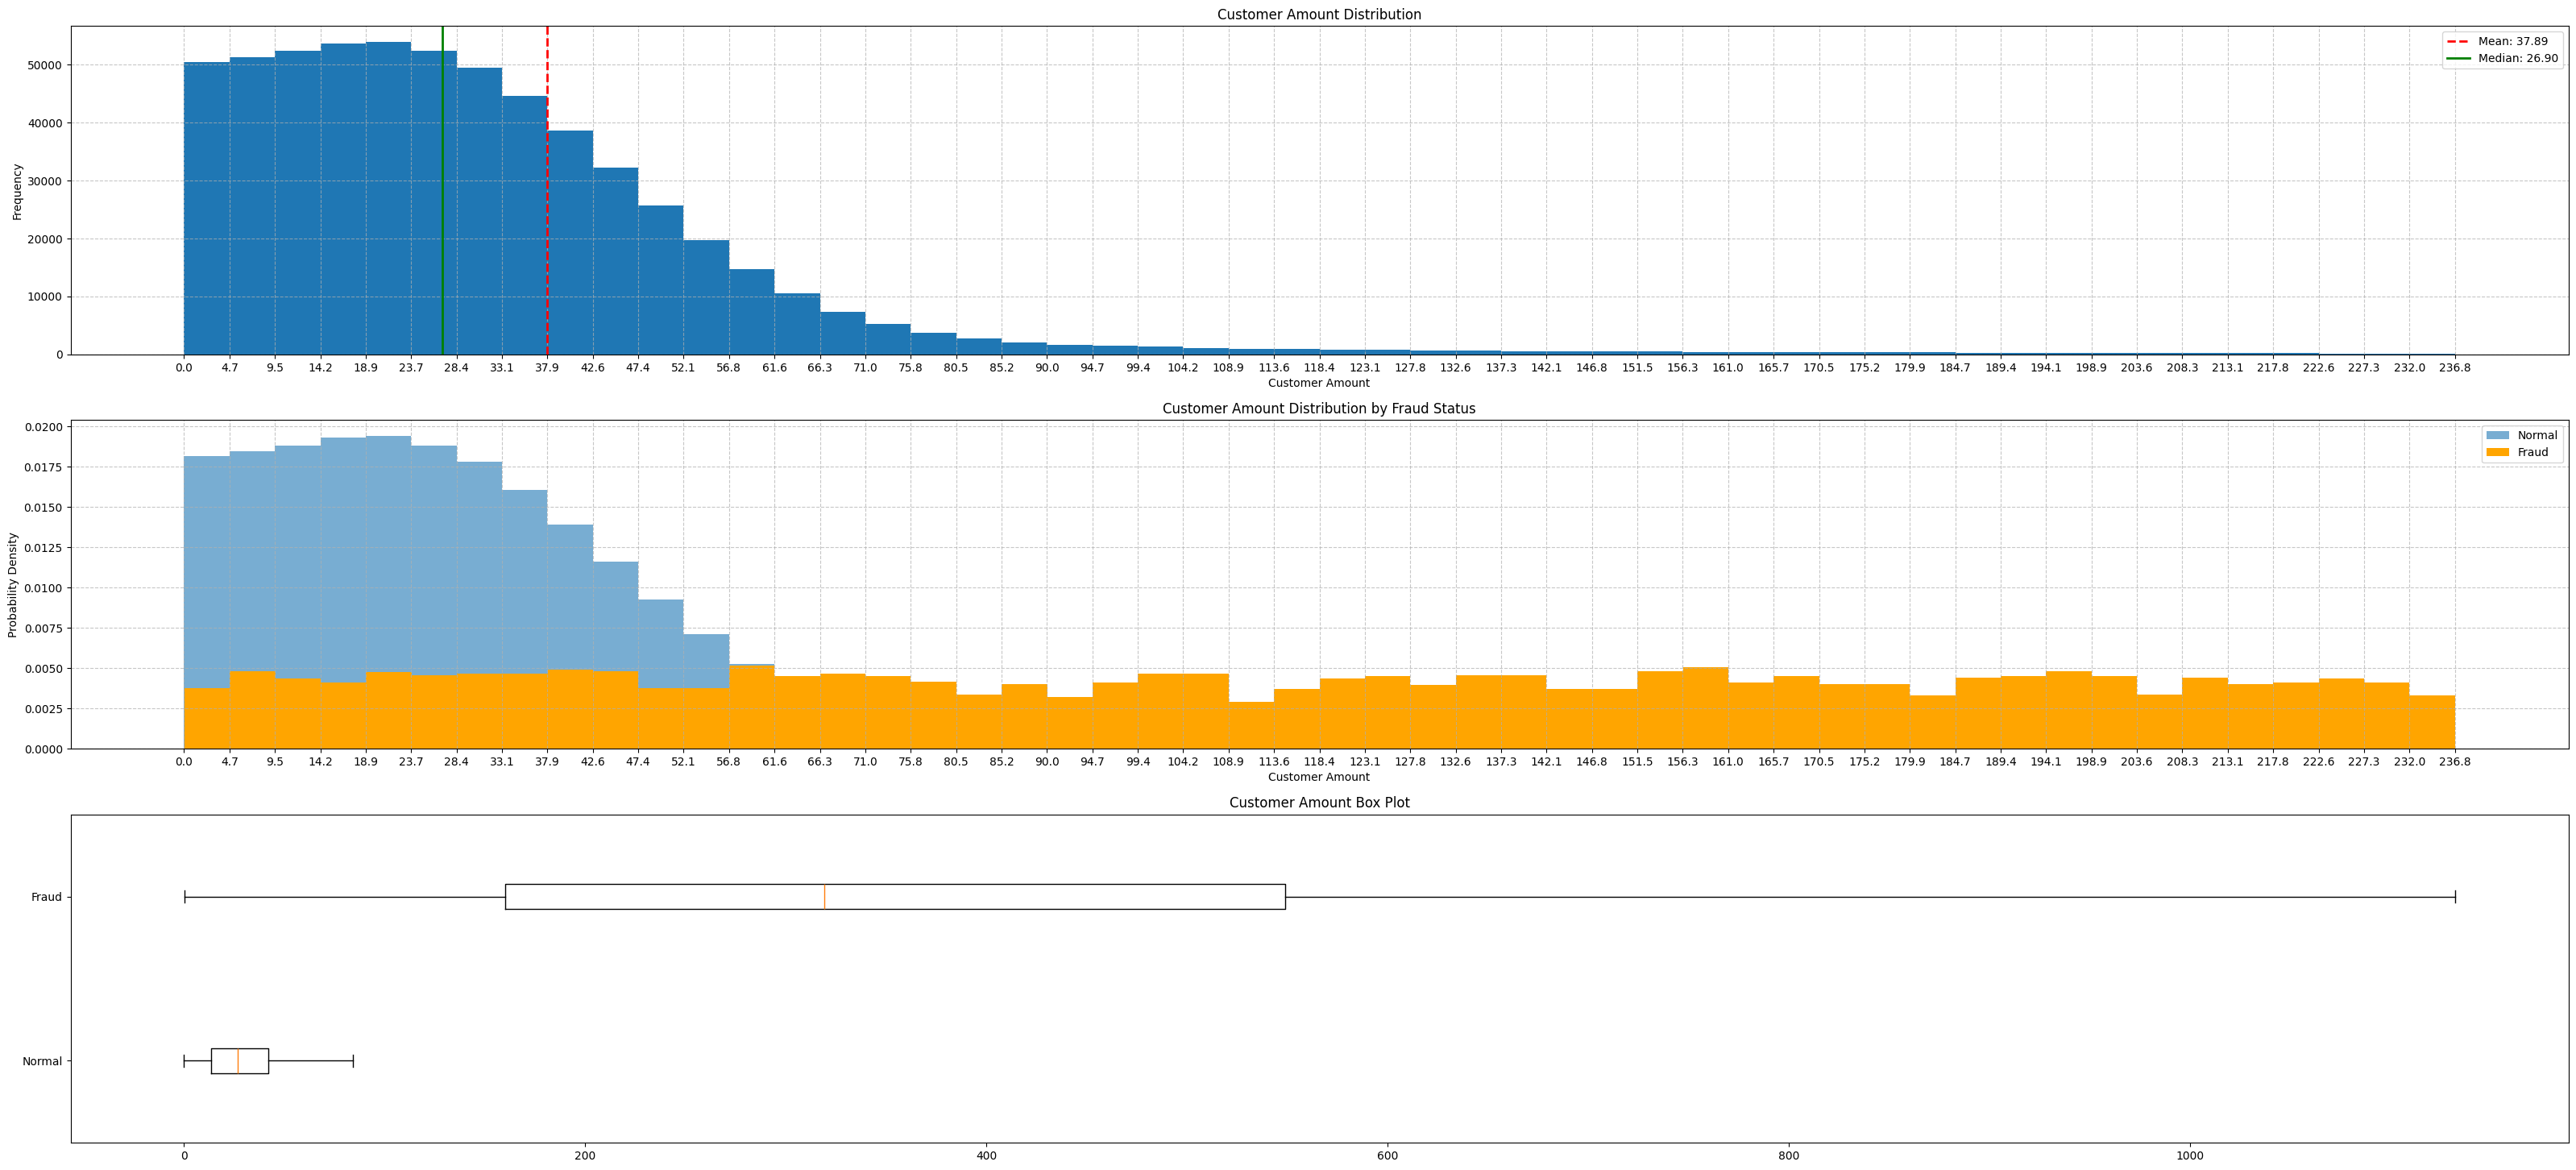

In [10]:
mean = df["customer_amount"].mean()
median = df["customer_amount"].median()
q99 = df["customer_amount"].quantile(0.99)

fraud_values = df["customer_amount"][df["fraud"] == 1]
normal_values = df["customer_amount"][df["fraud"] == 0]

fig, axes = plt.subplots(3, 1,figsize=(40, 18))

_, bin_edges, _ = axes[0].hist(df["customer_amount"], bins=50, range=(df["customer_amount"].min(),q99))

axes[0].set_title("Customer Amount Distribution")
axes[0].set_xticks(bin_edges)
axes[0].set_xlabel("Customer Amount")
axes[0].set_ylabel("Frequency")

axes[0].axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean:.2f}')
axes[0].axvline(median, color='green', linestyle='solid', linewidth=2, label=f'Median: {median:.2f}')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Density captures the probability distribution, probability = max_bin_width * height(density)
axes[1].hist(normal_values, bins=50, alpha=0.6, label='Normal', density=True, range=(normal_values.min(), q99))
axes[1].hist(fraud_values, bins=50, label='Fraud', color="orange", density=True, range=(fraud_values.min(), q99))

axes[1].set_title("Customer Amount Distribution by Fraud Status")
axes[1].set_xticks(bin_edges)
axes[1].set_xlabel("Customer Amount")
axes[1].set_ylabel("Probability Density")

axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[2].boxplot(
    [
        normal_values,
        fraud_values
    ],
    vert=False,
    showfliers=False,
    labels=["Normal", "Fraud"]
)
axes[2].set_title("Customer Amount Box Plot")


### Correlation Calculation and Visualisation
Sees if any two features have a linear relationship.

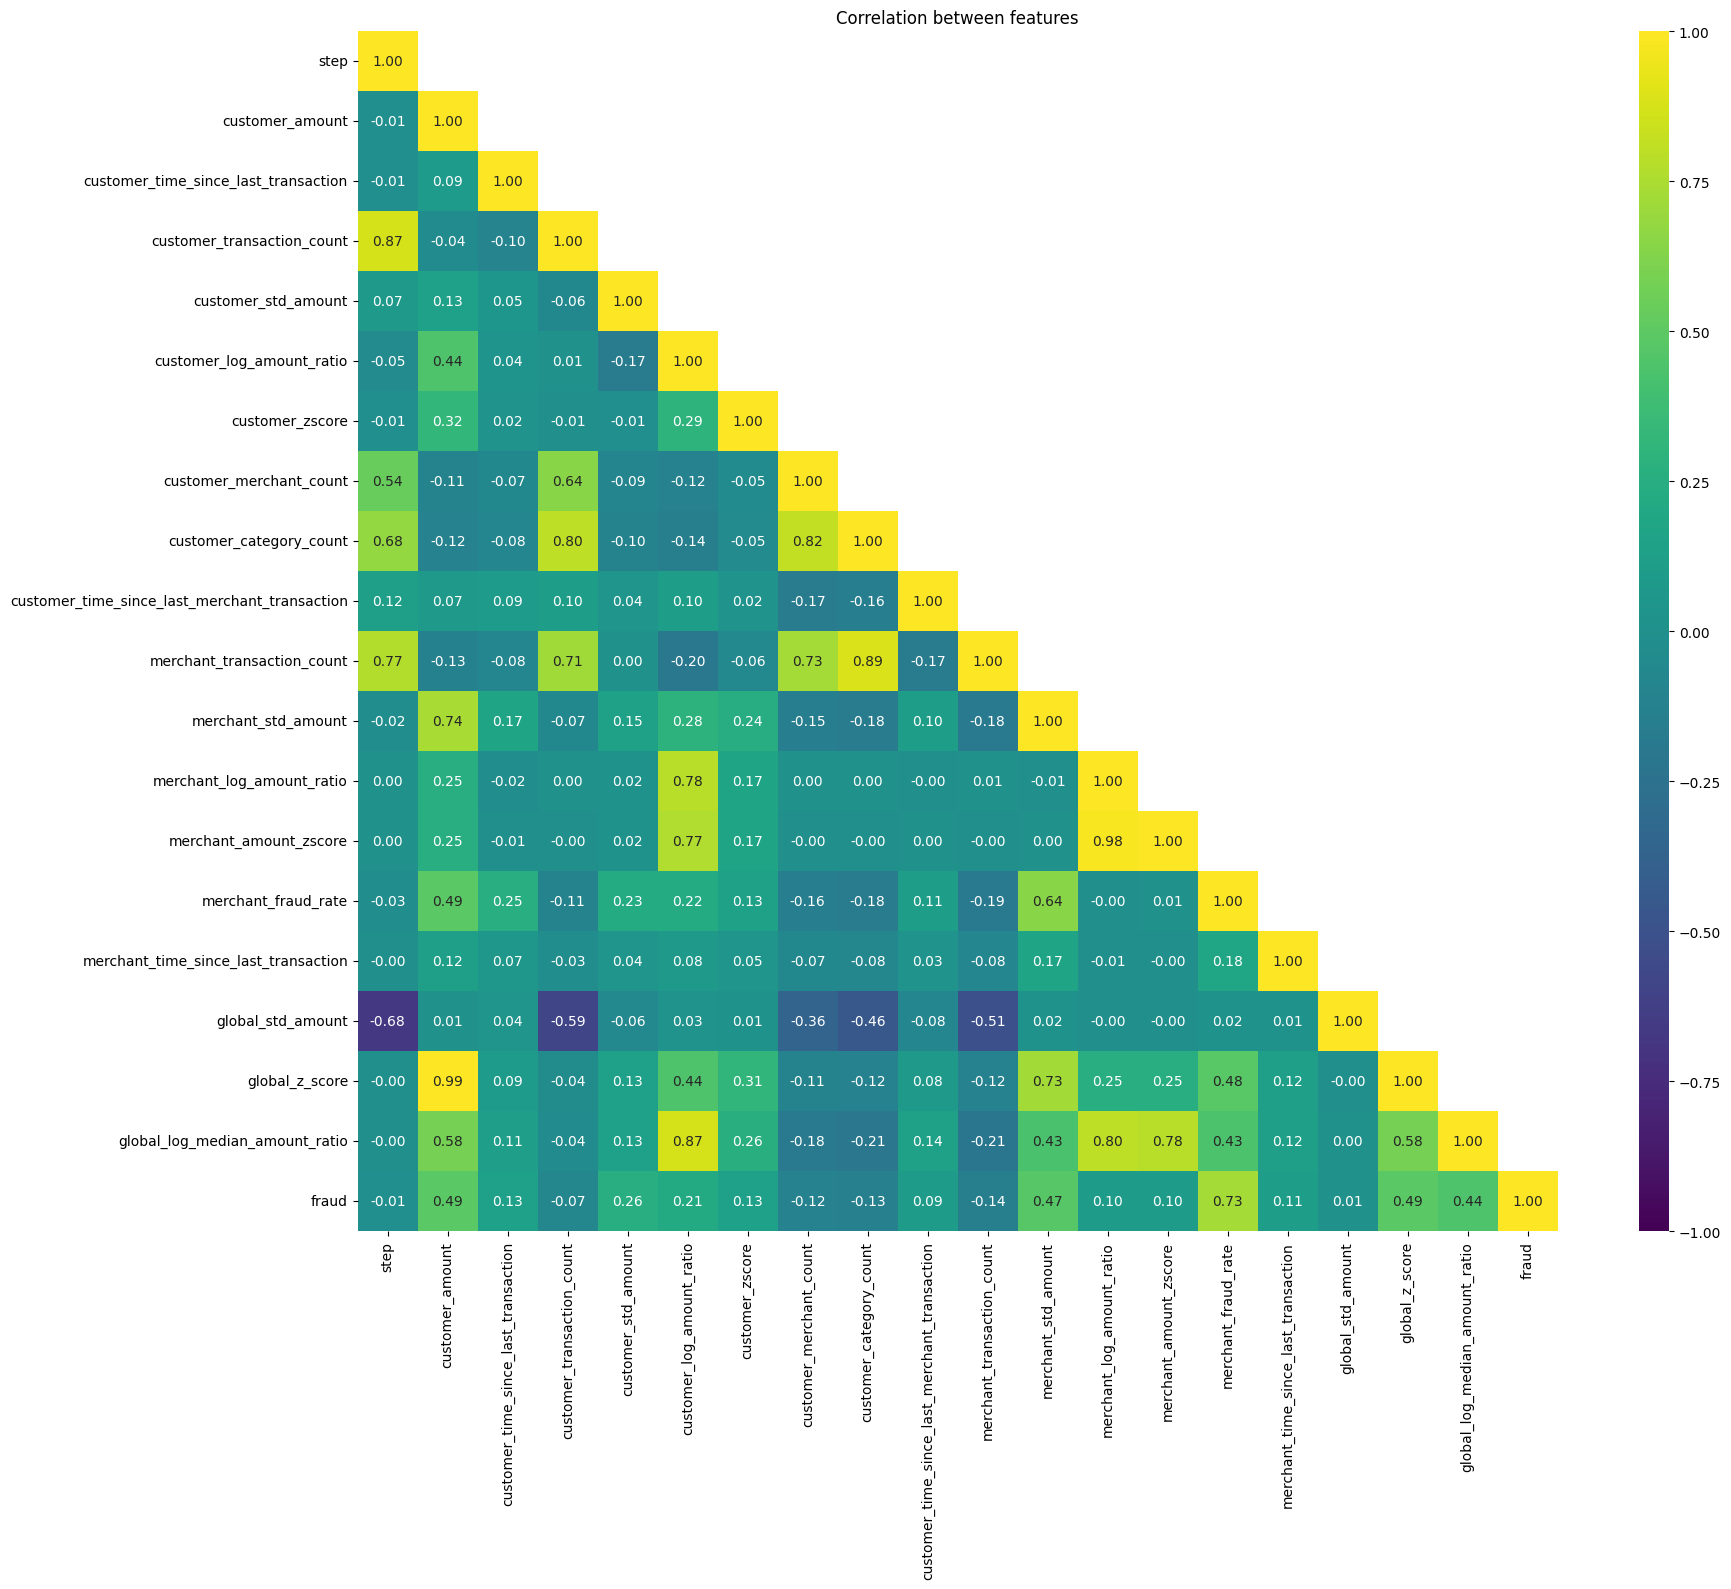

In [11]:
cor_cof= df[cont_cols + ["fraud"]].corr()
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix

plt.figure(figsize=(20, 16))
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10})
plt.title("Correlation between features")
plt.tight_layout()
plt.show()


In [12]:
target_corr = cor_cof['fraud']
target_corr_cont = target_corr[cont_cols] # Ignores binarry features as they are not useful for scatter plots

top2_vals = target_corr_cont.abs().sort_values(ascending=False)[:2] #Find the top 2 features most correlated with fraud
print(top2_vals)

top2_features = top2_vals.index.to_list()

merchant_fraud_rate    0.732199
customer_amount        0.489967
Name: fraud, dtype: float64


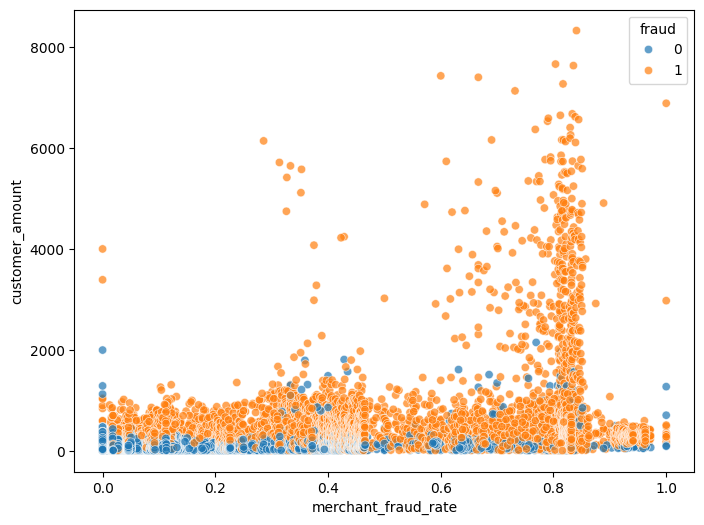

In [13]:
f1, f2 = top2_features

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df[f1],
    y=df[f2],
    hue=df['fraud'],
    alpha=0.7,
)

plt.show()

In [14]:
category_cols = [c for c in df.columns if c.startswith("category_")]

df.groupby("merchant")[category_cols].max().sum(axis=1).sort_values(ascending=False)

merchant
M1053599405    1
M117188757     1
M1198415165    1
M1294758098    1
M1313686961    1
M1352454843    1
M1353266412    1
M1400236507    1
M1416436880    1
M151143676     1
M1535107174    1
M1600850729    1
M1649169323    1
M1726401631    1
M17379832      1
M1741626453    1
M1748431652    1
M1788569036    1
M1823072687    1
M1842530320    1
M1872033263    1
M1873032707    1
M1888755466    1
M1913465890    1
M1946091778    1
M2011752106    1
M2080407379    1
M209847108     1
M2122776122    1
M348875670     1
M348934600     1
M349281107     1
M3697346       1
M45060432      1
M480139044     1
M495352832     1
M50039827      1
M547558035     1
M677738360     1
M692898500     1
M732195782     1
M78078399      1
M840466850     1
M855959430     1
M857378720     1
M85975013      1
M923029380     1
M933210764     1
M97925176      1
M980657600     1
dtype: int64

### Before data preparation

*Feature selection* - Are there features with no significance or zero variance?

*Feature scaling* - Are there numerical features with vastly different ranges?

*Data leakage* - Are there features that would not be available at the time of prediction but perfectly predict the output?

*Stratification* - Will the percentage of each class be roughly the same across data splits?

*Order* - Is your data time based? Can you shuffle it?

*Hidden bias* - Does data accurately represent the real world?
